In [2]:
# all the imports required for the project 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# read in the teams data from the csv file
teams = pd.read_csv('teams_data.csv')

teams = teams.drop(columns = ["logo"])
teams.head()



,team_id,country,team
0,50138,Italy,FC Internazionale Milano
1,50124,Spain,Atlético de Madrid
2,50111,Austria,SK Sturm Graz
3,52816,Italy,Atalanta BC
4,50050,Scotland,Celtic FC


In [4]:
# read in the players_data from the csv file 
players = pd.read_csv("DAY_4/players_data.csv")

# we drop the weight, player image and height columns as we will not be using these in our analysis and they contain plenty of missing values
# we drop the position column as this has many blank values and field position provides us the data we need for looking at countries that specialise in certain areas of the field
players = players.drop(columns = ["position", "player_image", "weight(kg)", "height(cm)"])

players.head()

# rename team_id cloumn to match teams df for merging 
players = players.rename(columns = {"id_team" : "team_id"})

In [5]:
# read in the key stats from the csv file 

key_stats = pd.read_csv("DAY_4/key_stats_data.csv")

key_stats.head()

,id_player,distance_covered(km/h),top_speed,minutes_played,matches_appareance
0,250016833,43.71,30.35,360.0,4.0
1,250105927,41.94,34.55,360.0,4.0
2,250121533,38.39,35.47,360.0,4.0
3,250121294,46.61,32.26,360.0,4.0
4,250160436,44.67,33.39,360.0,4.0


In [6]:
# read in all remaing csv files
attacking_stats = pd.read_csv("DAY_4/attacking_data.csv")
goals_stats = pd.read_csv("DAY_4/goals_data.csv")
goalkeeping_stats = pd.read_csv("DAY_4/goalkeeping_data.csv")
defending_stats = pd.read_csv("DAY_4/defending_data.csv")
distribution_stats = pd.read_csv("DAY_4/distribution_data.csv")
discipline_stats = pd.read_csv("DAY_4/disciplinary_data.csv")
attempts_stats = pd.read_csv("DAY_4/attempts_data.csv")

In [7]:
# gather some more info on the data frames we now have
players.info()

teams.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id_player       908 non-null    int64 
 1   player_name     908 non-null    object
 2   nationality     908 non-null    object
 3   field_position  908 non-null    object
 4   age             908 non-null    int64 
 5   team_id         908 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 42.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   team_id  36 non-null     int64 
 1   country  36 non-null     object
 2   team     36 non-null     object
dtypes: int64(1), object(2)
memory usage: 996.0+ bytes


In [8]:
# get info about key stats
key_stats.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_player               908 non-null    int64  
 1   distance_covered(km/h)  727 non-null    float64
 2   top_speed               727 non-null    float64
 3   minutes_played          727 non-null    float64
 4   matches_appareance      727 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 35.6 KB


In [9]:
# fix spelling error in key stats df 
key_stats = key_stats.rename(columns = {"matches_appareance"  : "appearances"})

# get unique values for field position column 
# this gives us the option to group players by position for analysis
players.field_position.unique()

array(['Forward', 'Midfielder', 'Defender', 'Goalkeeper'], dtype=object)

In [10]:
# any statistics relating to player performance that are null have this replace with 0 
key_stats = key_stats.fillna(0)
attacking_stats = attacking_stats.fillna(0)
goals_stats = goals_stats.fillna(0)
goalkeeping_stats = goalkeeping_stats.fillna(0)
defending_stats = defending_stats.fillna(0)
distribution_stats = distribution_stats.fillna(0)
discipline_stats = discipline_stats.fillna(0)
attempts_stats = attempts_stats.fillna(0)

In [11]:
# we want to export our data frames to sql so we can run queries on them from there 
import sqlite3

# Connect to database
conn = sqlite3.connect("ucl_analysis.db")

# Export player and teams tables
players.to_sql("players", conn, if_exists="replace", index=False)
teams.to_sql("teams", conn, if_exists="replace", index=False)

# Export all tables containung stats
key_stats.to_sql("key_stats", conn, if_exists="replace", index=False)
attacking_stats.to_sql("attacking_stats", conn, if_exists="replace", index=False)
defending_stats.to_sql("defending_stats", conn, if_exists="replace", index=False)
distribution_stats.to_sql("distribution_stats", conn, if_exists="replace", index=False)
goalkeeping_stats.to_sql("goalkeeping_stats", conn, if_exists="replace", index=False)
discipline_stats.to_sql("discipline_stats", conn, if_exists="replace", index=False)
goals_stats.to_sql("goals_stats", conn, if_exists ="replace", index = False)
attempts_stats.to_sql("attempts_stats", conn, if_exists="replace", index = False)

# close connection with database
conn.close()


In [12]:
# we now want to save the quries wrote into dataframes so we can use them in our analysis

# conect to the database
conn = sqlite3.connect("ucl_analysis.db")

# Query 1 - get the top 10 players with the most goals scored in the competition
query1 = """
SELECT player_name, goals, nationality, team, 
CASE
    WHEN nationality IN ('Spain', 'Italy', 'Germany', 'France', 'England') THEN 'Top 5 European Country'
    ELSE 'Other Country'
END AS Country_tier
FROM players
LEFT JOIN goals_stats ON players.id_player = goals_stats.id_player
INNER JOIN teams ON players.team_id = teams.team_id
ORDER BY goals DESC
LIMIT 10
"""

top_10_goal_scorers = pd.read_sql_query(query1, conn)

# Query 2 - get the top 10 players with the most assists in the competition
query2 = """
SELECT player_name, assists, nationality, team,
CASE
    WHEN nationality IN ('Spain', 'Italy', 'Germany', 'France', 'England') THEN 'Top 5 European Country'
    ELSE 'Other Country'
END AS Country_tier
FROM players
LEFT JOIN attacking_stats ON players.id_player = attacking_stats.id_player
INNER JOIN teams ON players.team_id = teams.team_id
ORDER BY assists DESC
LIMIT 10
"""

top_10_assist_scorers = pd.read_sql_query(query2, conn)

# Query 3 - get the top 10 players with the highest tackles won(%) in the competition
query3 = """
SELECT player_name, nationality, team, field_position, ROUND((tackles_won / tackles) * 100,2) AS "Tackles Won (%)",
CASE
    WHEN nationality IN ('Spain', 'Italy', 'Germany', 'France', 'England') THEN 'Top 5 European Country'
    ELSE 'Other Country'
END AS Country_tier
FROM players
LEFT JOIN key_stats ON players.id_player = key_stats.id_player
LEFT JOIN defending_stats ON players.id_player = defending_stats.id_player
INNER JOIN teams ON players.team_id = teams.team_id
WHERE tackles >= 5 AND minutes_played >= 180
GROUP BY player_name, nationality, team, field_position
ORDER BY "Tackles Won (%)" DESC
LIMIT 10;
"""

top_10_tackles_won = pd.read_sql_query(query3, conn)


In [13]:
# Query 4 - get the top 10 players with the highest goals per 90 minutes in the competition
query4 = """
SELECT player_name, nationality, team, field_position, ROUND((goals / (minutes_played / 90)),2) AS "Goals per 90 minutes",
CASE
    WHEN nationality IN ('Spain', 'Italy', 'Germany', 'France', 'England') THEN 'Top 5 European Country'
    ELSE 'Other Country'
END AS Country_tier
FROM players
LEFT JOIN goals_stats ON players.id_player = goals_stats.id_player
LEFT JOIN key_stats ON players.id_player = key_stats.id_player
INNER JOIN teams ON players.team_id = teams.team_id
WHERE minutes_played > 180 AND goals > 0
GROUP BY player_name, nationality, team, field_position
ORDER BY "Goals per 90 minutes" DESC
LIMIT 10;
"""

top_10_goals_per_90 = pd.read_sql_query(query4, conn)


In [14]:
 # Query 5 - get the top 10 players with the highest assists per 90 minutes in the competition

query5 = """
SELECT player_name, nationality, team, field_position, ROUND((assists / (minutes_played / 90)),2) AS "Assists per 90 minutes",
CASE
    WHEN nationality IN ('Spain', 'Italy', 'Germany', 'France', 'England') THEN 'Top 5 European Country'
    ELSE 'Other Country'
END AS Country_tier
FROM players
LEFT JOIN attacking_stats ON players.id_player = attacking_stats.id_player
LEFT JOIN key_stats ON players.id_player = key_stats.id_player
INNER JOIN teams ON players.team_id = teams.team_id
WHERE minutes_played > 180 AND assists > 0
GROUP BY player_name, nationality, team, field_position
ORDER BY "Assists per 90 minutes" DESC
LIMIT 10;
"""

top_10_assists_per_90 = pd.read_sql_query(query5, conn)



In [15]:
# query 6 - get the top 10 players with the highest ball recoveries per 90 minutes in the competition
query6 = """
SELECT player_name, nationality, team, field_position, ROUND((balls_recovered / (minutes_played / 90)),2) AS "Ball Recoveries per 90 minutes",
CASE
    WHEN nationality IN ('Spain', 'Italy', 'Germany', 'France', 'England') THEN 'Top 5 European Country'
    ELSE 'Other Country'
END AS Country_tier
FROM players
LEFT JOIN defending_stats ON players.id_player = defending_stats.id_player
LEFT JOIN key_stats ON players.id_player = key_stats.id_player
INNER JOIN teams ON players.team_id = teams.team_id
WHERE minutes_played > 180 AND balls_recovered > 0
GROUP BY player_name, nationality, team, field_position
ORDER BY "Ball Recoveries per 90 minutes" DESC
LIMIT 10;
"""
ball_recoveries_per_90 = pd.read_sql_query(query6, conn)

In [16]:
# Query 7 - get the top 10 goalkeepers with the highest clean sheets per 90 minutes in the competition
query7 = """
SELECT player_name, nationality, team, field_position, ROUND((clean_sheets / (minutes_played / 90)),2) AS "Clean Sheets per 90 minutes",
CASE
    WHEN nationality IN ('Spain', 'Italy', 'Germany', 'France', 'England') THEN 'Top 5 European Country'
    ELSE 'Other Country'
END AS Country_tier
FROM players
LEFT JOIN goalkeeping_stats ON players.id_player = goalkeeping_stats.id_player
LEFT JOIN key_stats ON players.id_player = key_stats.id_player
INNER JOIN teams ON players.team_id = teams.team_id
WHERE minutes_played > 180 AND clean_sheets > 0 AND field_position = 'Goalkeeper'
GROUP BY player_name, nationality, team, field_position
ORDER BY "Clean Sheets per 90 minutes" DESC
LIMIT 10;
"""
clean_sheets_per_90 = pd.read_sql_query(query7, conn)

In [17]:

top_10_assist_scorers.head()

,player_name,assists,nationality,team,Country_tier
0,Mohamed Salah,4.0,Egypt,Liverpool FC,Other Country
1,Joshua Kimmich,3.0,Germany,FC Bayern München,Top 5 European Country
2,Jules Koundé,3.0,France,FC Barcelona,Top 5 European Country
3,Ludovic Ajorque,3.0,France,Stade Brestois 29,Top 5 European Country
4,Igor Paixão,3.0,Brazil,Feyenoord,Other Country


In [18]:
top_10_tackles_won

,player_name,nationality,team,field_position,Tackles Won (%),Country_tier
0,Brendan Chardonnet,France,Stade Brestois 29,Defender,100.00,Top 5 European Country
1,Aïssa Mandi,Algeria,LOSC Lille,Defender,80.00,Other Country
2,Guram Kashia,Georgia,ŠK Slovan Bratislava,Defender,80.00,Other Country
3,Konrad Laimer,Austria,FC Bayern München,Midfielder,80.00,Other Country
4,Maxime Bernauer,France,GNK Dinamo,Defender,80.00,Top 5 European Country
5,Pierre Lees-Melou,France,Stade Brestois 29,Midfielder,80.00,Top 5 European Country
6,Conor Gallagher,England,Atlético de Madrid,Midfielder,77.78,Top 5 European Country
7,Emanuel Aiwu,Austria,SK Sturm Graz,Defender,77.78,Other Country
8,Jeff Chabot,Germany,VfB Stuttgart,Defender,71.43,Top 5 European Country
9,Thomas Partey,Ghana,Arsenal FC,Midfielder,71.43,Other Country


In [19]:
top_10_goal_scorers

,player_name,goals,nationality,team,Country_tier
0,Harry Kane,5.0,England,FC Bayern München,Top 5 European Country
1,Viktor Gyökeres,5.0,Sweden,Sporting Clube de Portugal,Other Country
2,Robert Lewandowski,5.0,Poland,FC Barcelona,Other Country
3,Raphinha,5.0,Brazil,FC Barcelona,Other Country
4,Vinícius Júnior,4.0,Brazil,Real Madrid C.F.,Other Country
5,Jonathan David,4.0,Canada,LOSC Lille,Other Country
6,Tijjani Reijnders,3.0,Netherlands,AC Milan,Other Country
7,Florian Wirtz,3.0,Germany,Bayer 04 Leverkusen,Top 5 European Country
8,Erling Haaland,3.0,Norway,Manchester City,Other Country
9,Dušan Vlahović,3.0,Serbia,Juventus,Other Country


In [20]:
top_10_goals_per_90

,player_name,nationality,team,field_position,Goals per 90 minutes,Country_tier
0,Raphinha,Brazil,FC Barcelona,Forward,1.43,Other Country
1,Robert Lewandowski,Poland,FC Barcelona,Forward,1.42,Other Country
2,Sandro Kulenović,Croatia,GNK Dinamo,Forward,1.38,Other Country
3,Jonathan David,Canada,LOSC Lille,Forward,1.34,Other Country
4,Luis Díaz,Colombia,Liverpool FC,Forward,1.28,Other Country
5,Harry Kane,England,FC Bayern München,Forward,1.25,Top 5 European Country
6,Viktor Gyökeres,Sweden,Sporting Clube de Portugal,Forward,1.25,Other Country
7,Abdallah Sima,Senegal,Stade Brestois 29,Forward,1.20,Other Country
8,Jamie Gittens,England,Borussia Dortmund,Midfielder,1.11,Top 5 European Country
9,Antoni Milambo,Netherlands,Feyenoord,Midfielder,1.09,Other Country


In [21]:
top_10_assists_per_90

,player_name,nationality,team,field_position,Assists per 90 minutes,Country_tier
0,Mohamed Salah,Egypt,Liverpool FC,Forward,1.08,Other Country
1,Arnaut Danjuma,Netherlands,Girona FC,Midfielder,0.98,Other Country
2,Ismael Saibari,Morocco,PSV Eindhoven,Forward,0.91,Other Country
3,Jeremie Frimpong,Netherlands,Bayer 04 Leverkusen,Defender,0.91,Other Country
4,Pedro Gonçalves,Portugal,Sporting Clube de Portugal,Midfielder,0.90,Other Country
5,Raphinha,Brazil,FC Barcelona,Forward,0.86,Other Country
6,Arne Engels,Belgium,Celtic FC,Midfielder,0.84,Other Country
7,Igor Paixão,Brazil,Feyenoord,Forward,0.82,Other Country
8,Ludovic Ajorque,France,Stade Brestois 29,Forward,0.80,Top 5 European Country
9,Jamal Musiala,Germany,FC Bayern München,Midfielder,0.78,Top 5 European Country


In [22]:
ball_recoveries_per_90

,player_name,nationality,team,field_position,Ball Recoveries per 90 minutes,Country_tier
0,Samson Baidoo,Austria,FC Salzburg,Defender,11.21,Other Country
1,Wilfried Singo,Ivory Coast,AS Monaco,Defender,10.33,Other Country
2,Willian Pacho,Ecuador,Paris Saint-Germain,Defender,10.25,Other Country
3,Florentino,Portugal,SL Benfica,Midfielder,9.55,Other Country
4,Axel Witsel,Belgium,Atlético de Madrid,Midfielder,8.63,Other Country
5,Gernot Trauner,Austria,Feyenoord,Defender,8.63,Other Country
6,Isak Hien,Sweden,Atalanta BC,Defender,8.33,Other Country
7,José María Giménez,Uruguay,Atlético de Madrid,Defender,8.33,Other Country
8,Alexsandro,Brazil,LOSC Lille,Defender,8.25,Other Country
9,Minjae Kim,Korea Republic,FC Bayern München,Defender,8.06,Other Country


In [23]:
clean_sheets_per_90

,player_name,nationality,team,field_position,Clean Sheets per 90 minutes,Country_tier
0,Marco Carnesecchi,Italy,Atalanta BC,Goalkeeper,1.00,Top 5 European Country
1,Yann Sommer,Switzerland,FC Internazionale Milano,Goalkeeper,1.00,Other Country
2,David Raya,Spain,Arsenal FC,Goalkeeper,0.75,Top 5 European Country
3,Lukas Hradecky,Finland,Bayer 04 Leverkusen,Goalkeeper,0.67,Other Country
4,Manuel Neuer,Germany,FC Bayern München,Goalkeeper,0.57,Top 5 European Country
5,Franco Israel,Uruguay,Sporting Clube de Portugal,Goalkeeper,0.50,Other Country
6,Simon Mignolet,Belgium,Club Brugge KV,Goalkeeper,0.50,Other Country
7,Gregor Kobel,Switzerland,Borussia Dortmund,Goalkeeper,0.33,Other Country
8,Ivan Nevistić,Croatia,GNK Dinamo,Goalkeeper,0.33,Other Country
9,Iñaki Peña,Spain,FC Barcelona,Goalkeeper,0.33,Top 5 European Country


In [24]:
# Query 8  get the combined G/A of all players grouped by nationality and field position
query8 = """
SELECT nationality, COUNT(DISTINCT players.id_player) AS "Number of Players", SUM(goals) AS "Total Goals", SUM(assists) AS "Total Assists", SUM(goals + assists) AS "Total G/A",
CASE
    WHEN nationality IN ('Spain', 'Italy', 'Germany', 'France', 'England') THEN 'Top 5 European Country'
    ELSE 'Other Country'
END AS Country_tier
FROM players
LEFT JOIN goals_stats ON players.id_player = goals_stats.id_player
LEFT JOIN attacking_stats ON players.id_player = attacking_stats.id_player
GROUP BY nationality
ORDER BY "Total G/A" DESC
"""

combined_ga_by_nationality = pd.read_sql_query(query8, conn)

combined_ga_by_nationality.head(10)

,nationality,Number of Players,Total Goals,Total Assists,Total G/A,Country_tier
0,Germany,67,20.0,19.0,39.0,Top 5 European Country
1,France,82,14.0,15.0,29.0,Top 5 European Country
2,Netherlands,53,14.0,10.0,24.0,Other Country
3,Spain,78,10.0,11.0,21.0,Top 5 European Country
4,Brazil,38,10.0,11.0,21.0,Other Country
5,England,42,14.0,5.0,19.0,Top 5 European Country
6,Croatia,23,9.0,7.0,16.0,Other Country
7,Belgium,36,5.0,11.0,16.0,Other Country
8,Portugal,38,5.0,10.0,15.0,Other Country
9,Nigeria,9,6.0,4.0,10.0,Other Country


In [25]:
# Query 9 - get the top players with the highest conversion rate in the competition
query9 = """
SELECT player_name, nationality, team, field_position, goals, total_attempts, ROUND((SUM(goals) / SUM(total_attempts)) * 100, 2) AS "Conversion Rate (%)",
CASE
    WHEN nationality IN ('Spain', 'Italy', 'Germany', 'France', 'England') THEN 'Top 5 European Country'
    ELSE 'Other Country'
END AS Country_tier
FROM players
LEFT JOIN goals_stats ON players.id_player = goals_stats.id_player
LEFT JOIN key_stats ON players.id_player = key_stats.id_player
LEFT JOIN attempts_stats ON players.id_player = attempts_stats.id_player
INNER JOIN teams ON players.team_id = teams.team_id
WHERE total_attempts > 0 AND goals > 0 AND minutes_played > 180 AND field_position = 'Forward'
GROUP BY player_name, nationality, team, field_position
ORDER BY "Conversion Rate (%)" DESC
LIMIT 10;
"""

top_10_conversion_rate = pd.read_sql_query(query9, conn)

top_10_conversion_rate 


,player_name,nationality,team,field_position,goals,total_attempts,Conversion Rate (%),Country_tier
0,Luis Díaz,Colombia,Liverpool FC,Forward,3.0,5.0,60.00,Other Country
1,Sandro Kulenović,Croatia,GNK Dinamo,Forward,3.0,5.0,60.00,Other Country
2,Abdallah Sima,Senegal,Stade Brestois 29,Forward,3.0,6.0,50.00,Other Country
3,Bruno Petković,Croatia,GNK Dinamo,Forward,2.0,4.0,50.00,Other Country
4,Cherif Ndiaye,Senegal,FK Crvena Zvezda,Forward,1.0,2.0,50.00,Other Country
5,Jonathan David,Canada,LOSC Lille,Forward,4.0,8.0,50.00,Other Country
6,Victor Olatunji,Nigeria,AC Sparta Praha,Forward,2.0,4.0,50.00,Other Country
7,Robert Lewandowski,Poland,FC Barcelona,Forward,5.0,13.0,38.46,Other Country
8,Kerem Aktürkoğlu,Türkiye,SL Benfica,Forward,3.0,8.0,37.50,Other Country
9,Julián Alvarez,Argentina,Atlético de Madrid,Forward,1.0,3.0,33.33,Other Country


C:\Users\aidan\AppData\Local\Temp\ipykernel_25328\3956633566.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="nationality", y="Total G/A", data=top_5_combined_ga_by_nationality, palette="viridis")


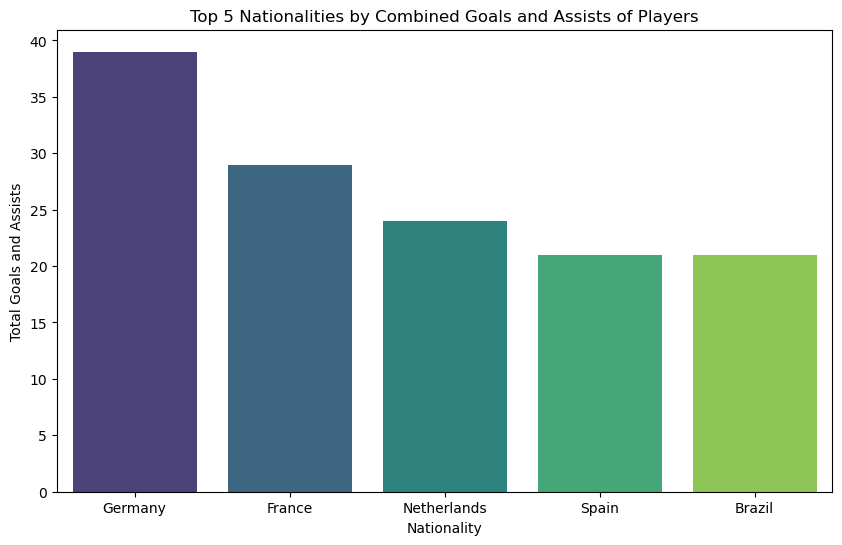

In [26]:
top_5_combined_ga_by_nationality = combined_ga_by_nationality.head(5)

# plot the top 5 nationalities with the highest combined G/A as a bar chart

plt.figure(figsize=(10,6))
sns.barplot(x="nationality", y="Total G/A", data=top_5_combined_ga_by_nationality, palette="viridis")
plt.title("Top 5 Nationalities by Combined Goals and Assists of Players")
plt.xlabel("Nationality")
plt.ylabel("Total Goals and Assists")
plt.show()

C:\Users\aidan\AppData\Local\Temp\ipykernel_25328\3531109871.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Country_tier", y="Goals per 90 minutes", data=top_10_goals_per_90, palette="Set2")


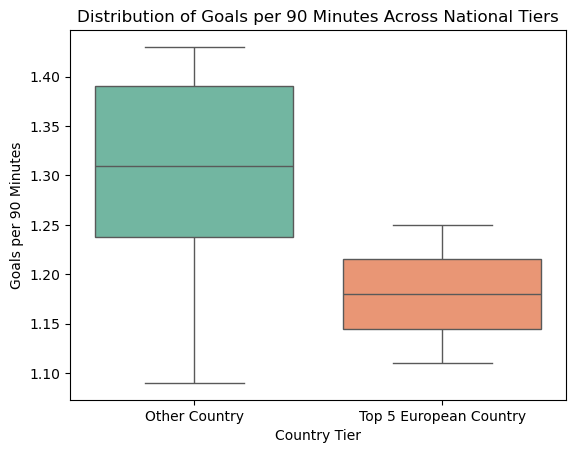

In [27]:
# show how goals per 90 are distributed across national tiers

sns.boxplot(x="Country_tier", y="Goals per 90 minutes", data=top_10_goals_per_90, palette="Set2")
plt.title("Distribution of Goals per 90 Minutes Across National Tiers")
plt.xlabel("Country Tier")
plt.ylabel("Goals per 90 Minutes")
plt.show()



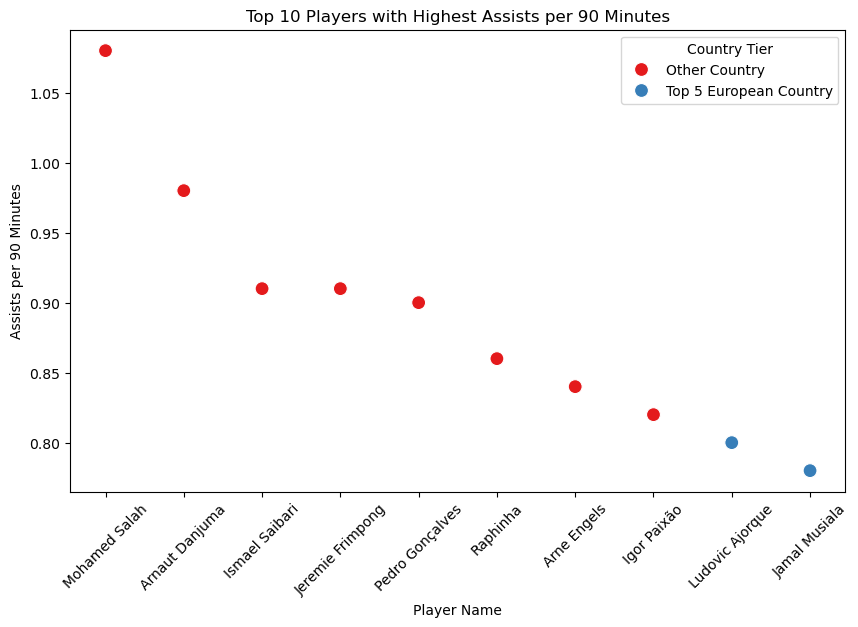

In [30]:
# show a scatter plot of the top 10 players with the highest assists per 90 minutes in the competition
# use country tier as the hue to show which players are from top 5 european countries and which are from other countries

plt.figure(figsize=(10,6))
sns.scatterplot(x="player_name", y="Assists per 90 minutes", hue="Country_tier", data=top_10_assists_per_90, palette="Set1", s=100)
plt.title("Top 10 Players with Highest Assists per 90 Minutes")
plt.xlabel("Player Name")
plt.ylabel("Assists per 90 Minutes")
plt.xticks(rotation=45)
plt.legend(title="Country Tier")
plt.show()

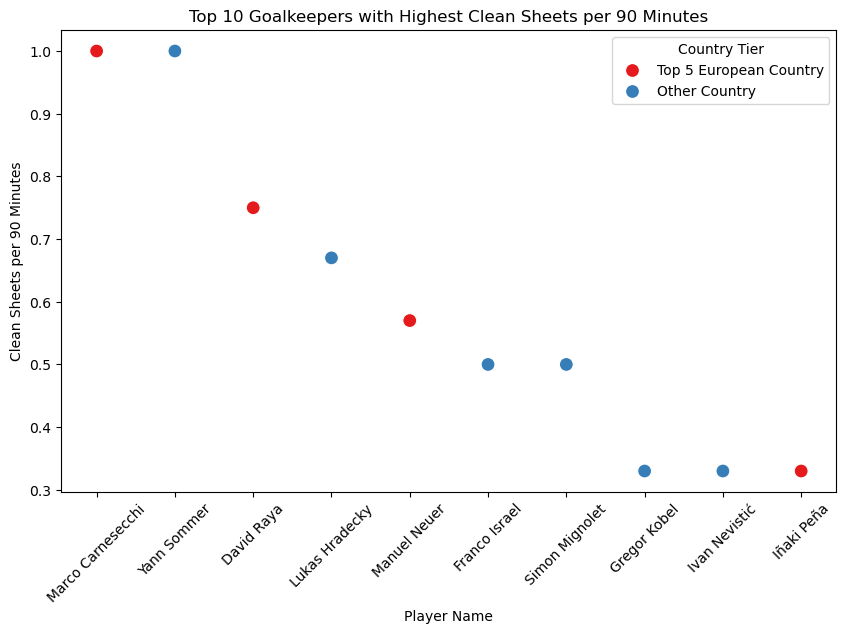

In [33]:
# display the clean sheets per 90 minutes for the top 10 goalkeepers as a scatter plot in the competition
plt.figure(figsize=(10,6))
sns.scatterplot(x="player_name", y="Clean Sheets per 90 minutes", hue="Country_tier", data=clean_sheets_per_90, palette="Set1", s=100)
plt.title("Top 10 Goalkeepers with Highest Clean Sheets per 90 Minutes")
plt.xlabel("Player Name")
plt.ylabel("Clean Sheets per 90 Minutes")
plt.xticks(rotation=45)
plt.legend(title="Country Tier")
plt.show()
